# D6 stage A — Five-moment repair

This notebook implements Eq. (5.16)'s finite correction with representative smooth bumps and prescribed discrepancies. It does not reconstruct the full first correction or evaluate its momentum residual.

In [1]:
import json
import numpy as np
from IPython.display import Image, display
from nscomp.d6 import STUDY, WRITING, load_parameters, setup, generate
from nscomp.moments import moment_matrices, solve_moments, original_moments, repaired_moments
p=load_parameters()
u_bumps,e_bumps=setup(p)
ef=p['patch_amplitude']/(1+p['eta']**2)
before=original_moments(p['d_u'],p['d_e'],ef)
print('Original five moments:',before)

Original five moments: [ 1.   0.3 -0.4 -0.4 -0.1]


## The two small moment systems

The axial block uses powers 1 and 1-2λ. The angular block uses powers 2, -2-2λ, and -2λ. The patch exponent λ differs from the correction-order power 2nh.

In [2]:
BU,BE=moment_matrices(p['lambda'],u_bumps,e_bumps,p['quadrature_order'])
alpha,beta=solve_moments(p['lambda'],u_bumps,e_bumps,p['d_u'],p['d_e'],p['quadrature_order'])
print('Axial matrix:\n',BU)
print('Angular matrix:\n',BE)
print('Axial coefficients:',alpha)
print('Angular coefficients:',beta)

Axial matrix:
 [[2.         3.        ]
 [1.74102182 2.40817594]]
Angular matrix:
 [[1.60022768e+01 2.50022768e+01 3.60022768e+01]
 [4.73898816e-02 2.90004838e-02 1.94161870e-02]
 [7.57871227e-01 7.24787586e-01 6.98832423e-01]]
Axial coefficients: [ 8.87154029 -6.24769353]
Angular coefficients: [ 21.09030117 -39.78267796  18.24508746]


## Reintegrate instead of checking only the solve

Use higher-order quadrature for the actual moment change, keeping the computed coefficients fixed. Separate tests use adaptive quadrature with the original patch pressure and momentum weights.

In [3]:
BU_ref,BE_ref=moment_matrices(p['lambda'],u_bumps,e_bumps,p['reference_order'])
after=repaired_moments(BU_ref,BE_ref,alpha,beta,before,ef)
print('Moments after repair:',after)
print('Componentwise relative remainders:',abs(after)/abs(before))

Moments after repair: [ 0.00000000e+00  3.84692278e-14  1.22124533e-15  2.22044605e-16
 -7.10542736e-15]
Componentwise relative remainders: [0.00000000e+00 1.28230759e-13 3.05311332e-15 5.55111512e-16
 7.10542736e-14]


## Conditioning

As λ approaches zero, the axial powers become nearly equal. These tests hold the discrepancies fixed; they do not follow an admissible family of full paper profiles.

In [4]:
for lam in (0.1,0.001,1e-6,1e-8):
    B,_=moment_matrices(lam,u_bumps,e_bumps)
    a,_=solve_moments(lam,u_bumps,e_bumps,p['d_u'],p['d_e'])
    print(f'lambda={lam:g}: cond(BU)={np.linalg.cond(B):.4g}, max|alpha|={np.max(abs(a)):.4g}')

lambda=0.1: cond(BU)=53.66, max|alpha|=8.872
lambda=0.001: cond(BU)=5345, max|alpha|=863.7
lambda=1e-06: cond(BU)=5.346e+06, max|alpha|=8.635e+05
lambda=1e-08: cond(BU)=5.346e+08, max|alpha|=8.635e+07


## Regenerate the study

Six CSV files contain matrices, coefficients, profiles, moments, quadrature convergence, and conditioning. The figures report moment remainders, not PDE residuals.

In [5]:
summary=generate()
print(json.dumps(summary,indent=2))

{
  "maximum_absolute_moment_remainder": 3.8469227803261674e-14,
  "maximum_relative_moment_remainder": 1.2823075934420558e-13,
  "baseline_condition_U": 53.656650057855785,
  "baseline_condition_E": 10937.529592732695,
  "baseline_max_axial_coefficient": 8.871540288773014,
  "smallest_lambda": 1e-08,
  "smallest_lambda_condition_U": 534574257.3717533,
  "smallest_lambda_relative_moment_remainder": 9.715621945849406e-08,
  "pde_residual_evaluated": false,
  "full_order_one_correction": false,
  "parameters_sha256": "901302090ae15300633922189ff409845e1af134bd4f1c4ff620bf1e15920bb6"
}


## Figures and next dependency

The finite step is ready to accept discrepancies from a future source-consistent inner extension. The implementation ledger records the missing joined leading profile, inner coefficient solve, and full residual comparison.

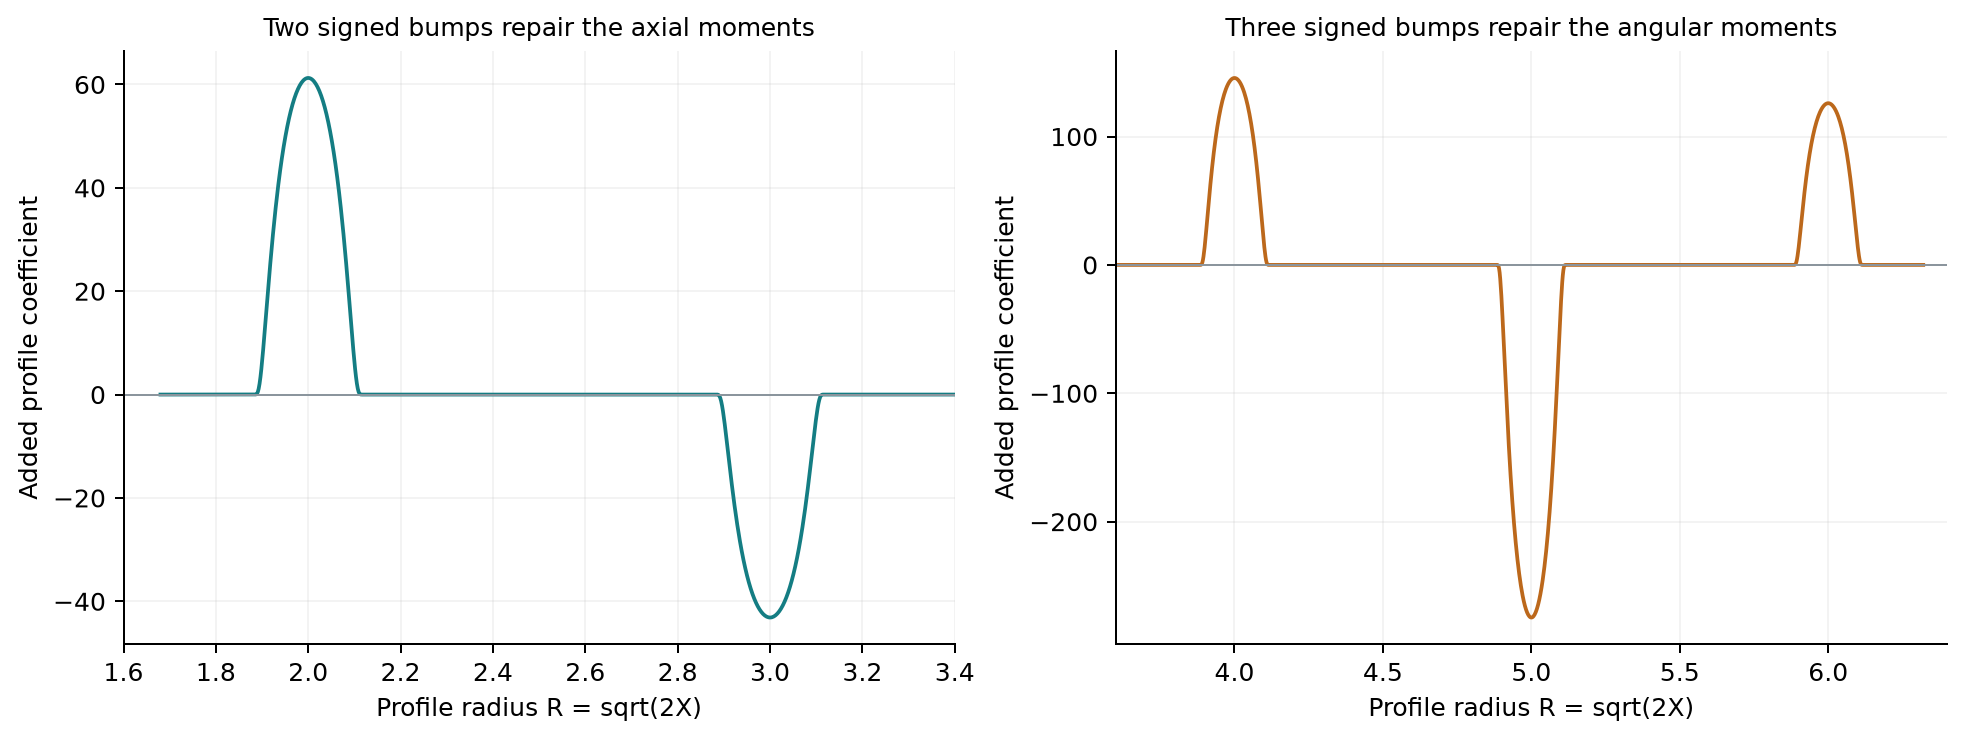

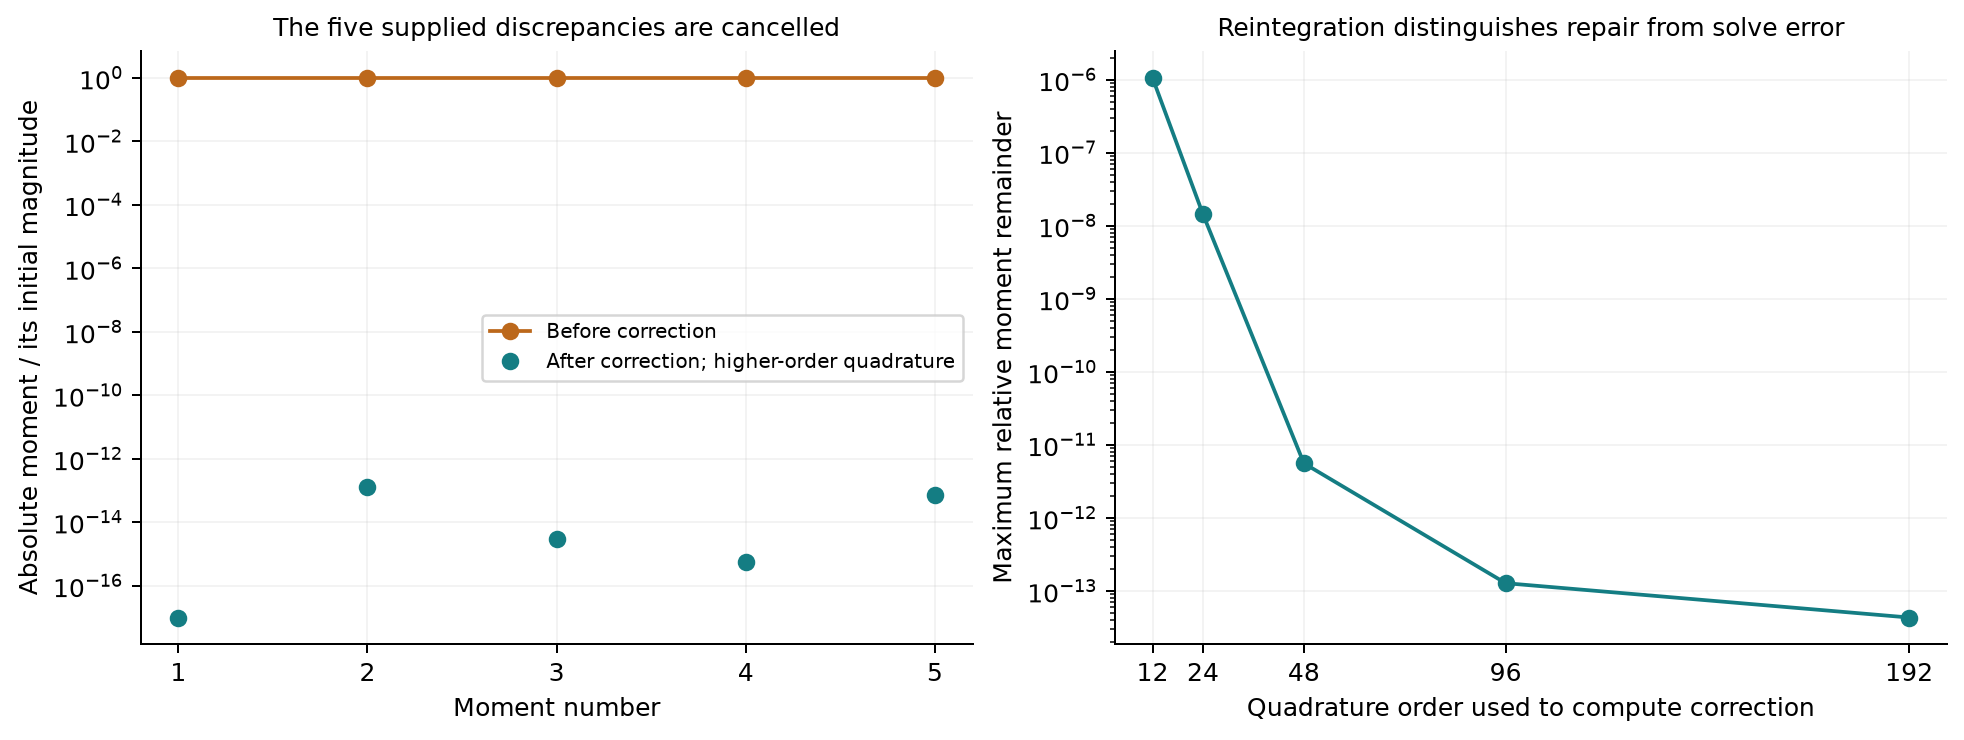

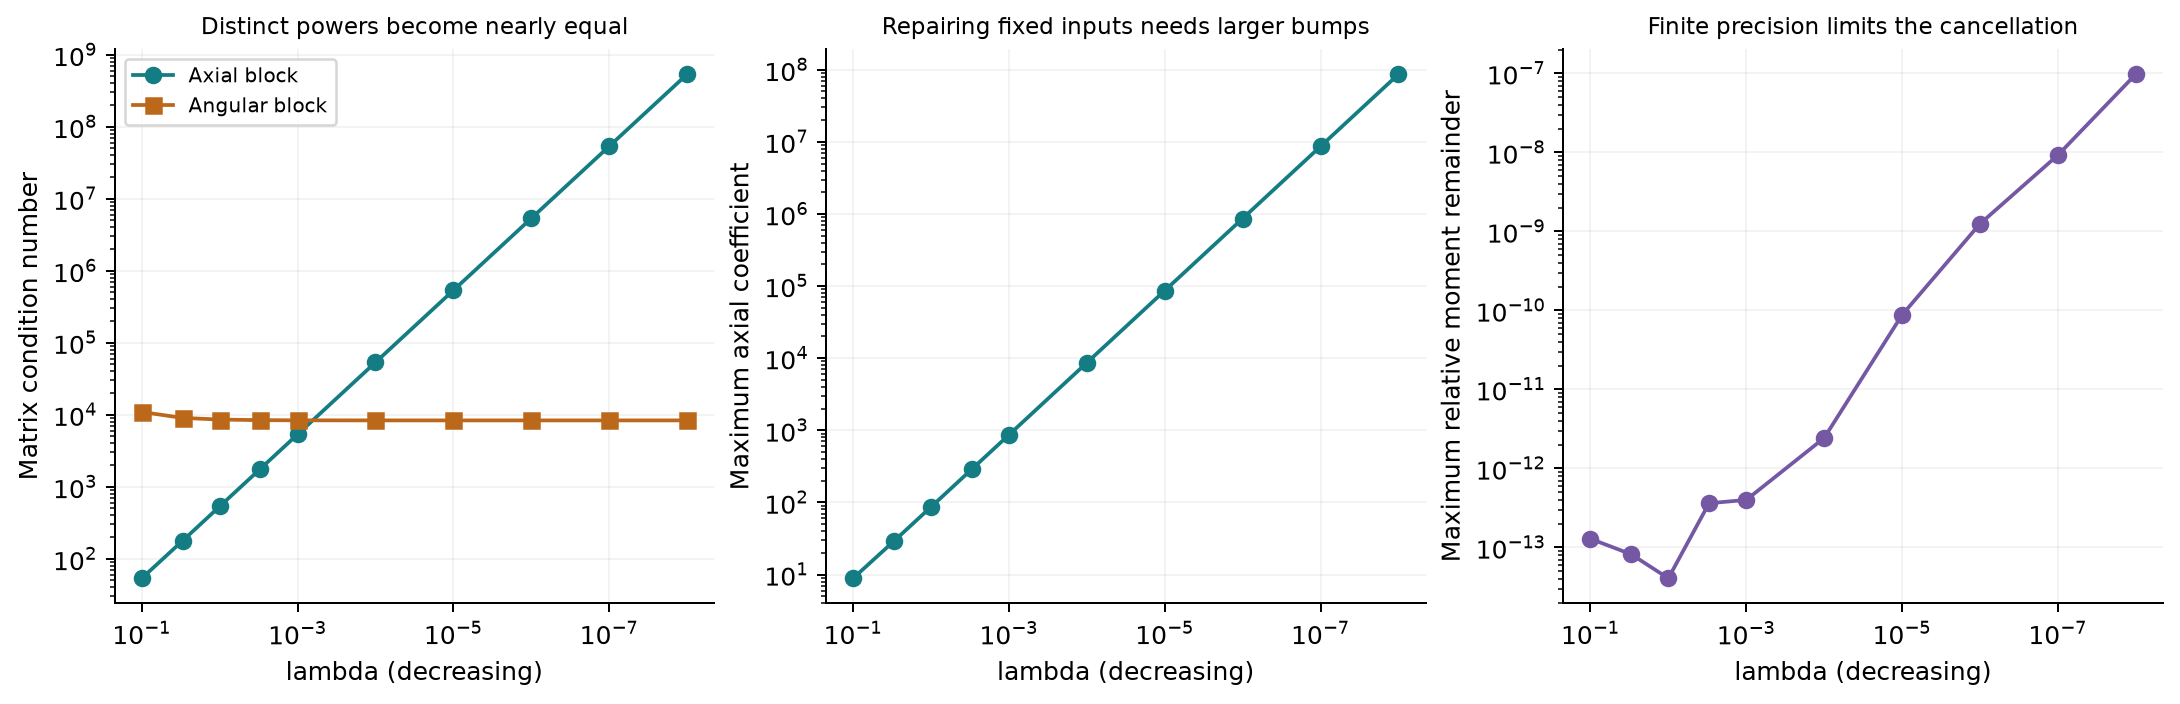

In [6]:
for name in ('01_local_profile_repair','02_moment_cancellation','03_conditioning_limit'):
    display(Image(filename=str(WRITING/'figures'/f'{name}.png')))